# QTran：Carinthia 五投影正式实验

本 Notebook 使用第二轮冻结配置，对 Carinthia 的四个参数匹配模型进行正式评估。由于最少类别只有4个样本，普通 70/15/15 分层切分无法保证每个集合都有全部类别，因此这里固定使用4折外层测试，并在每个外层训练分区内按类别划分验证集。

## 固定协议

- 每个外层测试折都包含全部6类，最少类别每折恰好1个测试样本；
- 外层测试样本不参与训练、早停或模型选择；
- 每个模型使用5个训练种子，每个种子训练4折，共 `4模型 × 5种子 × 4折 = 80` 个任务；
- 每个模型和种子的四折测试预测按原始样本编号拼接，得到覆盖全部4591张图一次的 OOF 结果；
- 论文主表使用5个种子级 OOF 指标，不把四折误当成独立重复实验；
- 每个任务独立保存并支持断点续跑。

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from qcs_core import plot_result_bars
from qcs_frozen_benchmark import (
    FORMAL_SEEDS,
    audit_carinthia_formal,
    formal_progress,
    load_frozen_selection,
    require_complete,
    run_carinthia_formal,
)
from qcs_multidataset import paired_model_comparisons

pd.set_option('display.max_columns', 100)
PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'qcs_frozen_benchmark.py').exists():
    raise RuntimeError('请从 /root/xxx/autodl 目录打开并运行本 Notebook')
PROJECT_DIR

/root/xxx/autodl/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/root/xxx/autodl')

## 1. 路径与冻结文件检查

In [2]:
CACHE_PATH = PROJECT_DIR / 'data_cache' / 'carinthia_32.npz'
FROZEN_SELECTION = (
    PROJECT_DIR
    / 'artifacts'
    / 'stability_search_stage2'
    / 'mixedwm38'
    / 'frozen_stage2_selection.json'
)
ARTIFACT_ROOT = PROJECT_DIR / 'artifacts' / 'three_datasets_five_projection'

for path in (CACHE_PATH, FROZEN_SELECTION):
    if not path.exists():
        raise FileNotFoundError(path)

frozen = load_frozen_selection(FROZEN_SELECTION)
display(pd.DataFrame([{
    'cache': str(CACHE_PATH),
    'frozen_selection': str(FROZEN_SELECTION),
    'artifact_root': str(ARTIFACT_ROOT),
    'selected_candidate_id': frozen.selected_candidate_id,
    'frozen_sha256': frozen.sha256,
}]))

,cache,frozen_selection,artifact_root,selected_candidate_id,frozen_sha256
0,/root/xxx/autodl/data_cache/carinthia_32.npz,/root/xxx/autodl/artifacts/stability_search_st...,/root/xxx/autodl/artifacts/three_datasets_five...,original_control,dc23ad480a5fc645fd995d0af6e9a97953746630015c63...


## 2. 四折协议审计

重点检查最少类别是否在每折的训练、验证和测试部分都存在，以及四模型参数量是否仍在公平范围内。

In [3]:
audit = audit_carinthia_formal(
    CACHE_PATH,
    FROZEN_SELECTION,
    split_seed=2026,
)
display(audit['frozen'])
display(pd.DataFrame([audit['dataset']]))
display(audit['classes'])
display(audit['folds'].pivot_table(
    index=['outer_fold', 'label'],
    columns='split',
    values='count',
))
display(audit['parameters'])

,selected_candidate_id,quantum_projection_mode,quantum_init_scale,quantum_lr_multiplier,quantum_pre_norm,epochs,patience,batch_size,train_cap_per_class,eval_cap_per_class,frozen_sha256
0,original_control,five,0.1,1.0,False,60,10,64,2000,None,dc23ad480a5fc645fd995d0af6e9a97953746630015c63...


,dataset,samples,image_shape,image_dtype,classes,groups,input_kind,split_strategy,cache_path
0,carinthia,4591,"(32, 32)",uint8,6,4591,grayscale,stratified,/root/xxx/autodl/data_cache/carinthia_32.npz


,class_id,label,count,fraction
0,0,class_1,55,0.011980
1,1,class_2,8,0.001743
2,2,class_3,4008,0.873012
3,3,class_4,289,0.062949
4,4,class_5,4,0.000871
5,5,class_6,227,0.049445


split                 test   train    val
outer_fold label                         
0          class_1    14.0    33.0    8.0
           class_2     2.0     5.0    1.0
           class_3  1002.0  2405.0  601.0
           class_4    72.0   174.0   43.0
           class_5     1.0     2.0    1.0
           class_6    57.0   136.0   34.0
1          class_1    14.0    33.0    8.0
           class_2     2.0     5.0    1.0
           class_3  1002.0  2405.0  601.0
           class_4    72.0   174.0   43.0
           class_5     1.0     2.0    1.0
           class_6    57.0   136.0   34.0
2          class_1    13.0    34.0    8.0
           class_2     2.0     5.0    1.0
           class_3  1002.0  2405.0  601.0
           class_4    73.0   173.0   43.0
           class_5     1.0     2.0    1.0
           class_6    57.0   136.0   34.0
3          class_1    14.0    33.0    8.0
           class_2     2.0     5.0    1.0
           class_3  1002.0  2405.0  601.0
           class_4    72.0   174.0   43.0
           class_5     1.0     2.0    1.0
           class_6    56.0   137.0   34.0

,model,parameters,relative_to_quantum
0,quantum_transformer,2178,0.000000
1,tiny_transformer,2234,0.025712
2,mlp_mixer,2236,0.026630
3,cnn_token_mixer,2194,0.007346


## 3. 查看断点续跑状态

In [4]:
progress_before = formal_progress(ARTIFACT_ROOT, 'carinthia', FORMAL_SEEDS)
display(progress_before.groupby('model')['complete'].agg(['sum', 'count']))
print(f"已完成 {int(progress_before['complete'].sum())}/{len(progress_before)} 个任务")

,sum,count
model,,
cnn_token_mixer,0,20
mlp_mixer,0,20
quantum_transformer,0,20
tiny_transformer,0,20


已完成 0/80 个任务


## 4. 运行或续跑80个正式任务

`MAX_JOBS=None` 表示运行所有剩余任务。建议首次可设为 `1` 检查一个任务；确认正常后改回 `None`。程序每完成一折就保存一次，服务器中断后重新执行本单元即可继续。

In [5]:
MAX_JOBS = None

carinthia_oof, carinthia_folds = run_carinthia_formal(
    cache_path=CACHE_PATH,
    frozen_selection_path=FROZEN_SELECTION,
    artifact_dir=ARTIFACT_ROOT,
    seeds=FORMAL_SEEDS,
    split_seed=2026,
    resume=True,
    max_jobs=MAX_JOBS,
)
print(f'当前已收集 {len(carinthia_folds)}/80 个折任务')
print(f'当前已形成 {len(carinthia_oof)}/20 个完整种子级 OOF 结果')
display(carinthia_oof)


[Carinthia] model=quantum_transformer, seed=42, fold=1/4, device=cuda



[Carinthia] model=quantum_transformer, seed=42, fold=2/4, device=cuda



[Carinthia] model=quantum_transformer, seed=42, fold=3/4, device=cuda



[Carinthia] model=quantum_transformer, seed=42, fold=4/4, device=cuda



[Carinthia] model=tiny_transformer, seed=42, fold=1/4, device=cuda


...


[Carinthia] model=cnn_token_mixer, seed=82, fold=2/4, device=cuda



[Carinthia] model=cnn_token_mixer, seed=82, fold=3/4, device=cuda



[Carinthia] model=cnn_token_mixer, seed=82, fold=4/4, device=cuda


当前已收集 80/80 个折任务
当前已形成 20/20 个完整种子级 OOF 结果


,dataset,model,seed,outer_folds,parameters,train_seconds,train_seconds_mean_per_fold,best_epoch,best_val_macro_f1,val_balanced_accuracy_at_best_f1,train_samples_mean,val_samples_mean,test_samples,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,recall_class_1,recall_class_2,recall_class_3,recall_class_4,recall_class_5,recall_class_6
0,carinthia,cnn_token_mixer,42,4,2194,78.719919,19.679980,17.50,0.388094,0.394069,2350.25,688.0,4591,0.910041,0.395236,0.403308,0.395236,0.398147,0.036364,0.000,0.957585,0.408304,0.00,0.969163
1,carinthia,mlp_mixer,42,4,2236,113.097653,28.274413,30.75,0.388869,0.389677,2350.25,688.0,4591,0.905685,0.377394,0.433179,0.377394,0.400698,0.090909,0.000,0.959331,0.522491,0.00,0.691630
2,carinthia,quantum_transformer,42,4,2178,827.442896,206.860724,19.50,0.388310,0.404635,2350.25,688.0,4591,0.908952,0.392961,0.453421,0.392961,0.412901,0.181818,0.000,0.961826,0.522491,0.00,0.691630
3,carinthia,tiny_transformer,42,4,2234,162.381187,40.595297,38.50,0.414484,0.428920,2350.25,688.0,4591,0.910259,0.447036,0.509165,0.447036,0.434749,0.109091,0.125,0.947355,0.553633,0.00,0.947137
4,carinthia,cnn_token_mixer,52,4,2194,74.031451,18.507863,21.50,0.363946,0.354397,2350.25,688.0,4591,0.928774,0.363645,0.611124,0.363645,0.399059,0.018182,0.000,0.989521,0.491349,0.00,0.682819
5,carinthia,mlp_mixer,52,4,2236,86.026009,21.506502,25.75,0.454795,0.470505,2350.25,688.0,4591,0.921368,0.412184,0.469961,0.412184,0.421602,0.072727,0.000,0.962575,0.671280,0.00,0.766520
6,carinthia,quantum_transformer,52,4,2178,1172.444491,293.111123,32.50,0.405737,0.420681,2350.25,688.0,4591,0.922893,0.420444,0.410340,0.420444,0.409560,0.000000,0.000,0.955589,0.826990,0.00,0.740088
7,carinthia,tiny_transformer,52,4,2234,112.437957,28.109489,26.75,0.407746,0.450490,2350.25,688.0,4591,0.905032,0.435117,0.417503,0.435117,0.424753,0.072727,0.125,0.943363,0.570934,0.00,0.898678
8,carinthia,cnn_token_mixer,62,4,2194,89.484440,22.371110,26.25,0.416776,0.451678,2350.25,688.0,4591,0.923546,0.437021,0.434527,0.437021,0.433172,0.109091,0.000,0.955090,0.844291,0.00,0.713656
9,carinthia,mlp_mixer,62,4,2236,97.700469,24.425117,28.75,0.414154,0.483837,2350.25,688.0,4591,0.894141,0.453290,0.401740,0.453290,0.420010,0.163636,0.000,0.933134,0.698962,0.25,0.674009


## 5. 完整性检查与 OOF 主结果

只有80/80个折任务完成后，才把 OOF 汇总用于论文模型比较。

In [6]:
progress_after = formal_progress(ARTIFACT_ROOT, 'carinthia', FORMAL_SEEDS)
display(progress_after.groupby('model')['complete'].agg(['sum', 'count']))
require_complete(progress_after, 'carinthia')

OOF_PATH = ARTIFACT_ROOT / 'carinthia' / 'carinthia_oof_results.csv'
carinthia_oof = pd.read_csv(OOF_PATH)
carinthia_summary = pd.read_csv(ARTIFACT_ROOT / 'carinthia' / 'summary.csv')
display(carinthia_summary)

carinthia_paired = paired_model_comparisons(
    carinthia_oof,
    metric='macro_f1',
)
carinthia_paired.to_csv(
    ARTIFACT_ROOT / 'carinthia' / 'paired_macro_f1.csv',
    index=False,
)
display(carinthia_paired)

,sum,count
model,,
cnn_token_mixer,20,20
mlp_mixer,20,20
quantum_transformer,20,20
tiny_transformer,20,20


,model,macro_f1_mean,macro_f1_std,balanced_acc_mean,balanced_acc_std,parameters,train_seconds_mean
0,quantum_transformer,0.421305,0.010619,0.414420,0.012798,2178,1004.113847
1,tiny_transformer,0.410916,0.025712,0.414314,0.036571,2234,131.670800
2,mlp_mixer,0.409582,0.070749,0.412581,0.089535,2236,100.370873
3,cnn_token_mixer,0.389470,0.046064,0.371752,0.061322,2194,90.478788


,dataset,reference,baseline,metric,paired_seeds,mean_difference,ci95_low,ci95_high,win_rate,paired_t_pvalue
0,carinthia,quantum_transformer,tiny_transformer,macro_f1,5,0.010389,-0.030381,0.051159,0.6,0.518306
1,carinthia,quantum_transformer,mlp_mixer,macro_f1,5,0.011723,-0.074056,0.097501,0.6,0.723649
2,carinthia,quantum_transformer,cnn_token_mixer,macro_f1,5,0.031835,-0.034465,0.098135,0.8,0.253345


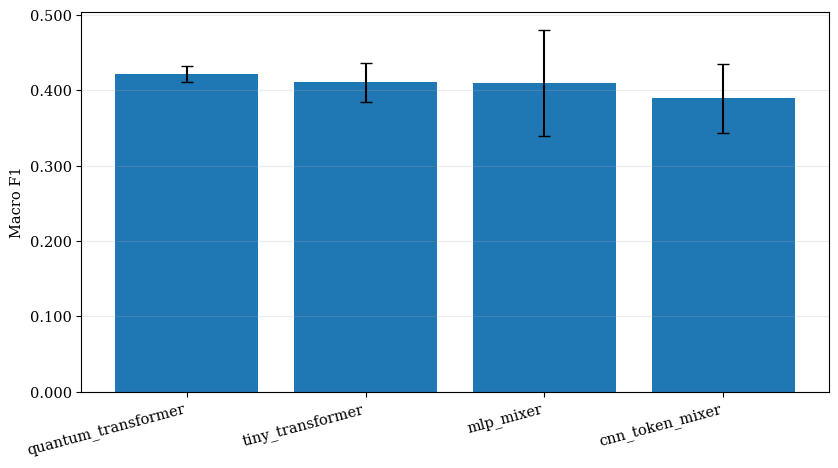

In [7]:
figure = plot_result_bars(carinthia_oof, metric='macro_f1')
figure.savefig(
    ARTIFACT_ROOT / 'carinthia' / 'formal_oof_macro_f1.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()

## 解释限制

最少类别总共只有4张图，因此该类别的召回率高度离散，单次误分类就会显著改变结果。论文应同时报告每类样本数、每类召回率、混淆矩阵和这一限制，不应把 Carinthia 单独作为“量子优势”的证据。完成后保留整个 `artifacts/three_datasets_five_projection/carinthia/` 文件夹。